In [1]:
try:
    import dolfinx
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" \
        -O "/tmp/fenicsx-install.sh"
    !bash "/tmp/fenicsx-install.sh"
    import dolfinx

print("FEniCSx version:", dolfinx.__version__)

--2026-08-26 09:49:13--  https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4339 (4.2K) [application/x-sh]
Saving to: ‘/tmp/fenicsx-install.sh’

/tmp/fenicsx-instal 100%[===================>]   4.24K  --.-KB/s    in 0s      

2026-08-26 09:49:13 (57.5 MB/s) - ‘/tmp/fenicsx-install.sh’ saved [4339/4339]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICSX_INSTALLED=/usr/local/share/fem-on-colab/fenicsx.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenicsx.installed ]]
+ PYBIND11_INSTALL_SCRIPT_PATH=https://github.com/fem-on-colab/fem-on-colab.github.io/raw/d829ee18/release

In [3]:
from mpi4py import MPI
import dolfinx

print("FEniCSx version:", dolfinx.__version__)
print("MPI processes:", MPI.COMM_WORLD.size)

FEniCSx version: 0.11.0.post0
MPI processes: 1


In [10]:
!pip -q install meshio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 3.9 MB/s eta 0:00:00


In [22]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import ufl

from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import fem, mesh, io
from dolfinx.fem.petsc import NonlinearProblem

# ============================================================
# 1. GEOMETRY
# ============================================================

comm = MPI.COMM_WORLD

L = 1.0
Nx = 31
number_of_elements = Nx - 1
dX = L / number_of_elements

domain = mesh.create_interval(
    comm,
    number_of_elements,
    [0.0, L]
)

# Three-component displacement on a 1D cable
V = fem.functionspace(
    domain,
    ("Lagrange", 1, (3,))
)

# ============================================================
# 2. MATERIAL AND CABLE PROPERTIES
# ============================================================

E = 4.456e8
diameter = 1.0e-3
A = np.pi * diameter**2 / 4.0

rho = 970.0
rhoA = rho * A

EA = E * A

# Equivalent to the MATLAB segment quantities
l0 = dX
k_segment = EA / l0

c_edge = 1.0e-6
c_node = 1.0e-6

print("EA =", EA, "N")
print("Segment stiffness =", k_segment, "N/m")
print("Mass per unit length =", rhoA, "kg/m")

# ============================================================
# 3. TIME PARAMETERS
# ============================================================

# Short initial test
Tend = 2.00
dt = 2.0e-4
save_every = 20

number_of_steps = int(round(Tend / dt))
time = np.linspace(0.0, Tend, number_of_steps + 1)

# Newmark parameters
beta = 0.25
gamma = 0.50

# ============================================================
# 12. PARAVIEW VTK OUTPUT
# ============================================================

output_folder = "fenicsx_cable_vtk"

if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

os.makedirs(output_folder)

pvd_path = os.path.join(
    output_folder,
    "fenicsx_cable_motion.pvd"
)

vtk_file = io.VTKFile(
    comm,
    pvd_path,
    "w"
)

# Initial displacement
vtk_file.write_function(u, 0.0)

# ============================================================
# 4. PRESCRIBED RIGHT-END MOTION
# ============================================================

amplitude = 0.03 * L
omega = 2.0 * np.pi
Tramp = 1.0

def ramp_function(t):
    if t <= Tramp:
        return 0.5 * (1.0 - np.cos(np.pi * t / Tramp))
    return 1.0

def right_boundary_displacement(t):
    ramp = ramp_function(t)

    return np.array([
        0.0,
        amplitude * ramp * np.cos(omega * t),
        amplitude * ramp * np.sin(omega * t)
    ], dtype=PETSc.ScalarType)

# ============================================================
# 5. SOLUTION VARIABLES
# ============================================================

# Unknown displacement at t_(n+1)
u = fem.Function(V, name="Displacement")

# Previous displacement, velocity and acceleration
u_n = fem.Function(V, name="Previous_displacement")
v_n = fem.Function(V, name="Previous_velocity")
a_n = fem.Function(V, name="Previous_acceleration")

# Initial conditions are zero
u.x.array[:] = 0.0
u_n.x.array[:] = 0.0
v_n.x.array[:] = 0.0
a_n.x.array[:] = 0.0

# ============================================================
# 6. BOUNDARY CONDITIONS
# ============================================================

left_dofs = fem.locate_dofs_geometrical(
    V,
    lambda x: np.isclose(x[0], 0.0)
)

right_dofs = fem.locate_dofs_geometrical(
    V,
    lambda x: np.isclose(x[0], L)
)

left_value = fem.Constant(
    domain,
    np.zeros(3, dtype=PETSc.ScalarType)
)

right_value = fem.Constant(
    domain,
    np.zeros(3, dtype=PETSc.ScalarType)
)

bc_left = fem.dirichletbc(
    left_value,
    left_dofs,
    V
)

bc_right = fem.dirichletbc(
    right_value,
    right_dofs,
    V
)

boundary_conditions = [bc_left, bc_right]

# ============================================================
# 7. NEWMARK EXPRESSIONS
# ============================================================

test_function = ufl.TestFunction(V)

a_new = (
    (u - u_n - dt * v_n) / (beta * dt**2)
    -
    ((1.0 - 2.0 * beta) / (2.0 * beta)) * a_n
)

v_new = (
    v_n
    +
    dt * ((1.0 - gamma) * a_n + gamma * a_new)
)

# ============================================================
# 8. GEOMETRICALLY NONLINEAR CABLE KINEMATICS
# ============================================================

# Current position derivative:
#
# r(X,t) = [X + u_x, u_y, u_z]
#
r_X = ufl.as_vector((
    1.0 + u[0].dx(0),
    u[1].dx(0),
    u[2].dx(0)
))

v_X = ufl.as_vector((
    v_new[0].dx(0),
    v_new[1].dx(0),
    v_new[2].dx(0)
))

test_X = ufl.as_vector((
    test_function[0].dx(0),
    test_function[1].dx(0),
    test_function[2].dx(0)
))

small_number = 1.0e-12

stretch = ufl.sqrt(
    ufl.dot(r_X, r_X) + small_number
)

# Time derivative of stretch
stretch_rate = (
    ufl.dot(r_X, v_X) / stretch
)

# Elastic contribution
elastic_tension = EA * (stretch - 1.0)

# Equivalent element dashpot contribution:
# element length rate = l0 * stretch_rate
viscous_tension = c_edge * l0 * stretch_rate

trial_tension = elastic_tension + viscous_tension

# Tension-only constitutive law
tension = ufl.conditional(
    ufl.gt(stretch, 1.0),
    ufl.max_value(trial_tension, 0.0),
    0.0
)

# Current unit tangent
current_tangent = r_X / stretch

# ============================================================
# 9. WEAK RESIDUAL
# ============================================================

dx = ufl.dx

# Inertial term
inertial_residual = (
    rhoA
    * ufl.inner(a_new, test_function)
    * dx
)

# Small distributed damping corresponding approximately to
# nodal damping c_node
distributed_damping = c_node / dX

damping_residual = (
    distributed_damping
    * ufl.inner(v_new, test_function)
    * dx
)

# Geometrically nonlinear internal cable force
internal_residual = (
    tension
    * ufl.inner(current_tangent, test_X)
    * dx
)

residual = (
    inertial_residual
    + damping_residual
    + internal_residual
)

# ============================================================
# 10. NONLINEAR PETSC PROBLEM
# ============================================================

problem = NonlinearProblem(
    residual,
    u,
    bcs=boundary_conditions,
    petsc_options_prefix="nonlinear_cable_",
    petsc_options={
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1.0e-8,
        "snes_atol": 1.0e-10,
        "snes_max_it": 30,
        "snes_error_if_not_converged": True,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "ksp_error_if_not_converged": True
    }
)

# ============================================================
# 11. ARRAYS FOR RESULTS
# ============================================================

dof_coordinates = V.tabulate_dof_coordinates()
node_order = np.argsort(dof_coordinates[:, 0])

reference_x = dof_coordinates[node_order, 0]

middle_local_index = np.argmin(
    np.abs(reference_x - L / 2.0)
)

mid_y = np.zeros(number_of_steps + 1)
mid_z = np.zeros(number_of_steps + 1)

max_stretch = np.ones(number_of_steps + 1)
max_tension = np.zeros(number_of_steps + 1)

# ============================================================
# 12. PARAVIEW OUTPUT
# ============================================================

output_folder = "fenicsx_cable_results"

if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

os.makedirs(output_folder)

xdmf_path = os.path.join(
    output_folder,
    "fenicsx_cable_motion.xdmf"
)

xdmf_file = io.XDMFFile(
    comm,
    xdmf_path,
    "w"
)

xdmf_file.write_mesh(domain)
xdmf_file.write_function(u, 0.0)

# ============================================================
# 13. TIME INTEGRATION
# ============================================================

for step in range(1, number_of_steps + 1):

    current_time = step * dt

    # Update prescribed right-end displacement
    right_value.value[:] = right_boundary_displacement(
        current_time
    )

    # Use previous displacement as Newton initial guess
    u.x.array[:] = u_n.x.array

    # Apply new boundary value to the initial guess
    bc_left.set(u.x.array)
    bc_right.set(u.x.array)

    # Solve nonlinear dynamic equilibrium
    problem.solve()

    # Confirm convergence
    convergence_reason = problem.solver.getConvergedReason()

    if convergence_reason <= 0:
        raise RuntimeError(
            f"Nonlinear solver failed at t={current_time}"
        )

    # --------------------------------------------------------
    # Newmark state update using coefficient arrays
    # --------------------------------------------------------

    u_array = u.x.array.copy()
    u_n_array = u_n.x.array.copy()
    v_n_array = v_n.x.array.copy()
    a_n_array = a_n.x.array.copy()

    a_new_array = (
        (u_array - u_n_array - dt * v_n_array)
        / (beta * dt**2)
        -
        ((1.0 - 2.0 * beta) / (2.0 * beta))
        * a_n_array
    )

    v_new_array = (
        v_n_array
        +
        dt * (
            (1.0 - gamma) * a_n_array
            +
            gamma * a_new_array
        )
    )

    # Save new state
    u_n.x.array[:] = u_array
    v_n.x.array[:] = v_new_array
    a_n.x.array[:] = a_new_array

    u_n.x.scatter_forward()
    v_n.x.scatter_forward()
    a_n.x.scatter_forward()

    # --------------------------------------------------------
    # Calculate midpoint response and maximum stretch
    # --------------------------------------------------------

    nodal_displacement = u_array.reshape((-1, 3))
    nodal_displacement = nodal_displacement[node_order]

    current_positions = np.zeros((Nx, 3))
    current_positions[:, 0] = (
        reference_x + nodal_displacement[:, 0]
    )
    current_positions[:, 1] = nodal_displacement[:, 1]
    current_positions[:, 2] = nodal_displacement[:, 2]

    segment_vectors = np.diff(
        current_positions,
        axis=0
    )

    segment_lengths = np.linalg.norm(
        segment_vectors,
        axis=1
    )

    stretch_values = segment_lengths / l0
    elastic_tensions = EA * np.maximum(
        stretch_values - 1.0,
        0.0
    )

    mid_y[step] = current_positions[
        middle_local_index, 1
    ]

    mid_z[step] = current_positions[
        middle_local_index, 2
    ]

    max_stretch[step] = np.max(stretch_values)
    max_tension[step] = np.max(elastic_tensions)

    # --------------------------------------------------------
    # Write time-dependent result
    # --------------------------------------------------------

    if step % save_every == 0:
        vtk_file.write_function(
            u,
            current_time
        )

    if step % 100 == 0:
        print(
            f"Step {step:5d}/{number_of_steps}, "
            f"t = {current_time:.4f} s, "
            f"max(lambda) = {max_stretch[step]:.6f}"
        )

vtk_file.close()

print("FEniCSx cable simulation completed.")

EA = 349.9734216099029 N
Segment stiffness = 10499.202648297087 N/m
Mass per unit length = 0.0007618362184955247 kg/m
Step   100/10000, t = 0.0200 s, max(lambda) = 1.000000
Step   200/10000, t = 0.0400 s, max(lambda) = 1.000000
Step   300/10000, t = 0.0600 s, max(lambda) = 1.000001
Step   400/10000, t = 0.0800 s, max(lambda) = 1.000003
Step   500/10000, t = 0.1000 s, max(lambda) = 1.000004
Step   600/10000, t = 0.1200 s, max(lambda) = 1.000006
Step   700/10000, t = 0.1400 s, max(lambda) = 1.000008
Step   800/10000, t = 0.1600 s, max(lambda) = 1.000011
Step   900/10000, t = 0.1800 s, max(lambda) = 1.000014
Step  1000/10000, t = 0.2000 s, max(lambda) = 1.000017
Step  1100/10000, t = 0.2200 s, max(lambda) = 1.000021
Step  1200/10000, t = 0.2400 s, max(lambda) = 1.000026
Step  1300/10000, t = 0.2600 s, max(lambda) = 1.000030
Step  1400/10000, t = 0.2800 s, max(lambda) = 1.000036
Step  1500/10000, t = 0.3000 s, max(lambda) = 1.000041
Step  1600/10000, t = 0.3200 s, max(lambda) = 1.000047
St

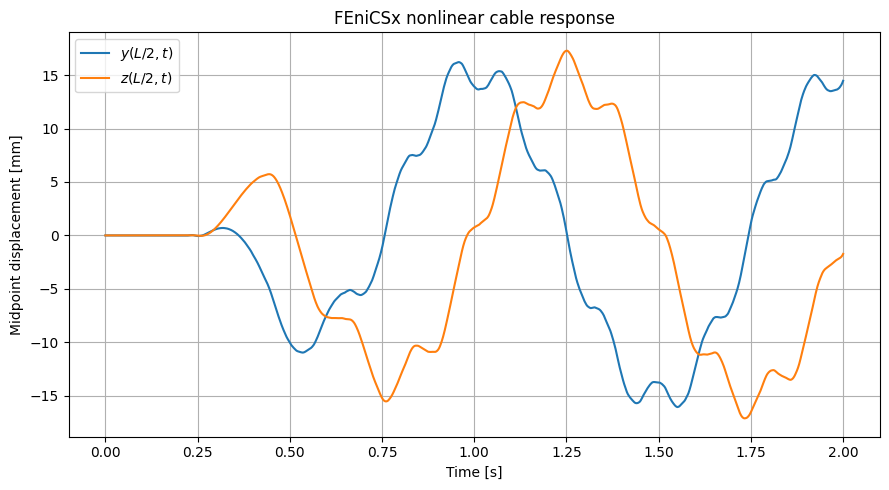

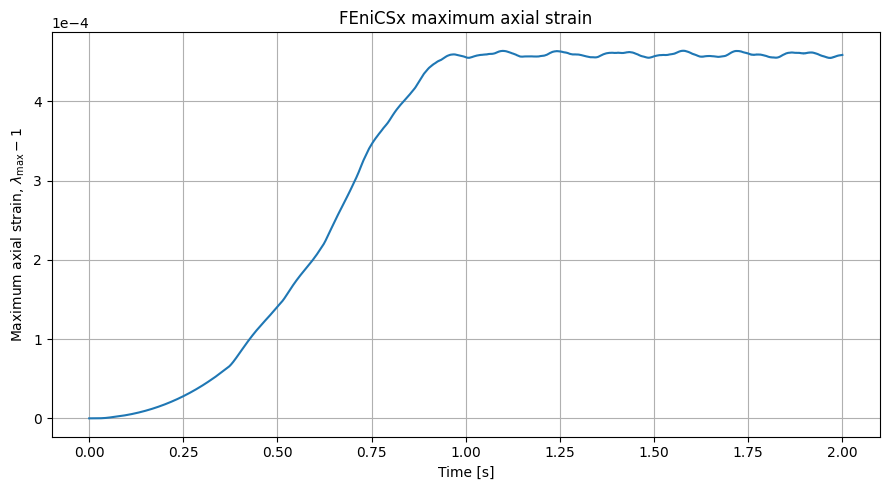

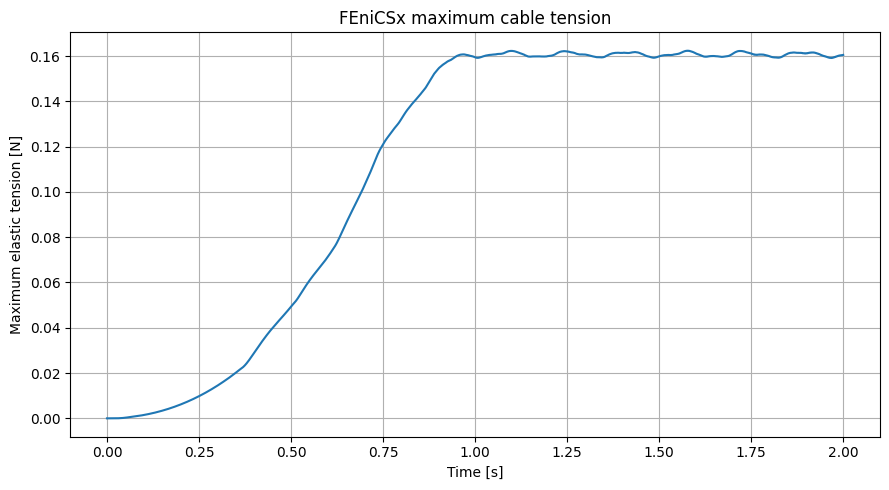

In [23]:
# Midpoint displacement in millimetres
plt.figure(figsize=(9, 5))

plt.plot(time, 1e3 * mid_y, label=r"$y(L/2,t)$")
plt.plot(time, 1e3 * mid_z, label=r"$z(L/2,t)$")

plt.xlabel("Time [s]")
plt.ylabel("Midpoint displacement [mm]")
plt.title("FEniCSx nonlinear cable response")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Maximum axial strain
maximum_strain = max_stretch - 1.0

plt.figure(figsize=(9, 5))

plt.plot(time, maximum_strain)

plt.xlabel("Time [s]")
plt.ylabel(r"Maximum axial strain, $\lambda_{\max}-1$")
plt.title("FEniCSx maximum axial strain")
plt.ticklabel_format(
    axis="y",
    style="scientific",
    scilimits=(0, 0)
)
plt.grid(True)
plt.tight_layout()
plt.show()

# Maximum elastic tension
plt.figure(figsize=(9, 5))

plt.plot(time, max_tension)

plt.xlabel("Time [s]")
plt.ylabel("Maximum elastic tension [N]")
plt.title("FEniCSx maximum cable tension")
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
shutil.make_archive(
    "fenicsx_cable_vtk",
    "zip",
    "fenicsx_cable_vtk"
)

from google.colab import files
files.download("fenicsx_cable_vtk.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>